Question5. Develop a program to calculate histogram and make histogram
equalization for given images. Test the program on suitable images.
Display histogram plots of the original and equalized images.



Histogram! It is the alpha and the omega of image processing.
You may have never heard of a histogram before, but it's nothing.
It's a kind of bar graph of the frequency distribution table, so let's get to know what you mean and what you need to do step by step.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

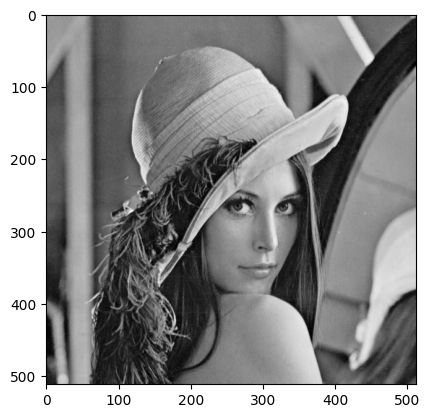

In [12]:
from matplotlib.pyplot import gray


img = cv2.imread('../Lenna.png')
img =cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
# plt.subplot(1,2,1)
# plt.imshow(img)

#plt.subplot(1,2,2)
plt.imshow(gray,cmap='gray')
plt.show()

In [3]:
print(img.shape)   
print(gray.shape)


(512, 512, 3)
(512, 512)


This photo is called lenna, maybe the most famous woman for the image engineers.   
The color images we see are three channels of RGB and The gray image have only one channel.  
If you new to image processing, you may wonder between relation between image and 8-bit,  
In 8 bit image, every pixels has a range of 0 to 255.  256 = $ 2^8 $ bits. then, what is pixel? seeing your monitor, you may check your display spec. like 1920 x 1080   
it means your monitor have 1920 x 1080 pixels.  
Based on the black-and-white picture (Gray Scaled Image), the image is stored in an array by dividing the grid like a checkerboard   
(Based on 8 bits) Each array element (pixel) has a value of 0-255. The closer you get to zero, the closer you get to black, the closer you get to 255 the closer you get to white.  
Shall we take a look at the example?

(array([1.1500e+02, 6.3500e+02, 2.5940e+03, 4.6990e+03, 7.2870e+03,
        1.0332e+04, 7.1860e+03, 6.7810e+03, 3.7890e+03, 3.2490e+03,
        4.0680e+03, 3.5100e+03, 4.6050e+03, 3.8420e+03, 4.3330e+03,
        6.6700e+03, 7.3840e+03, 9.3800e+03, 6.2800e+03, 5.4170e+03,
        6.9970e+03, 6.5200e+03, 1.0184e+04, 9.5170e+03, 8.6260e+03,
        9.8190e+03, 9.3440e+03, 1.1706e+04, 9.1630e+03, 1.0728e+04,
        1.1121e+04, 6.2940e+03, 6.2050e+03, 5.0460e+03, 4.6540e+03,
        4.1440e+03, 2.5610e+03, 3.6620e+03, 3.7420e+03, 3.4430e+03,
        4.5010e+03, 4.1520e+03, 4.4560e+03, 1.8090e+03, 1.1300e+03,
        3.3600e+02, 1.0100e+02, 2.2000e+01, 1.0000e+00, 4.0000e+00]),
 array([ 25. ,  29.4,  33.8,  38.2,  42.6,  47. ,  51.4,  55.8,  60.2,
         64.6,  69. ,  73.4,  77.8,  82.2,  86.6,  91. ,  95.4,  99.8,
        104.2, 108.6, 113. , 117.4, 121.8, 126.2, 130.6, 135. , 139.4,
        143.8, 148.2, 152.6, 157. , 161.4, 165.8, 170.2, 174.6, 179. ,
        183.4, 187.8, 192.2, 196.6

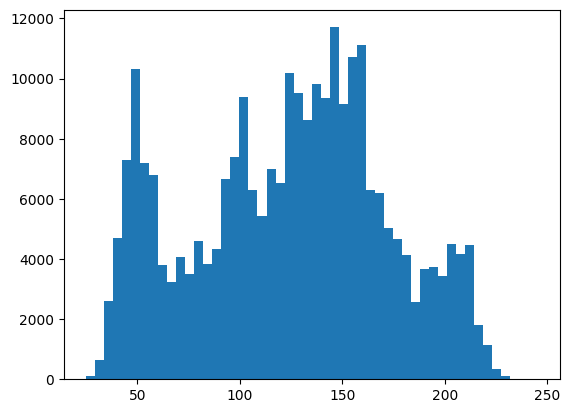

In [4]:
flat_gray = gray.flatten()
plt.hist(flat_gray,bins=50)

A distribution map of Image has been completed!  
The reason why the graph is up to 12000 on the Y-axis is because the image size is 512*512.  
There are 262,144 pixels in this image.  
Then, let's take a look at the image with 3 channels of rgb  

(array([  927.,  3409.,  7206.,  9847.,  9761.,  7668.,  5608.,  4976.,
         5309.,  6886., 12324., 20779., 23903., 24168., 25206., 26425.,
        28425., 32072., 32268., 29532., 25919., 24599., 24922., 25711.,
        24905., 25536., 18039., 15089., 13250., 13052., 13193., 12140.,
        11991., 13629., 14777., 13811., 14003., 14109., 14548., 16824.,
        20300., 16279., 15462., 20456., 14911., 10741., 11237.,  6300.,
         2786.,  1214.]),
 array([  3.  ,   8.04,  13.08,  18.12,  23.16,  28.2 ,  33.24,  38.28,
         43.32,  48.36,  53.4 ,  58.44,  63.48,  68.52,  73.56,  78.6 ,
         83.64,  88.68,  93.72,  98.76, 103.8 , 108.84, 113.88, 118.92,
        123.96, 129.  , 134.04, 139.08, 144.12, 149.16, 154.2 , 159.24,
        164.28, 169.32, 174.36, 179.4 , 184.44, 189.48, 194.52, 199.56,
        204.6 , 209.64, 214.68, 219.72, 224.76, 229.8 , 234.84, 239.88,
        244.92, 249.96, 255.  ]),
 <BarContainer object of 50 artists>)

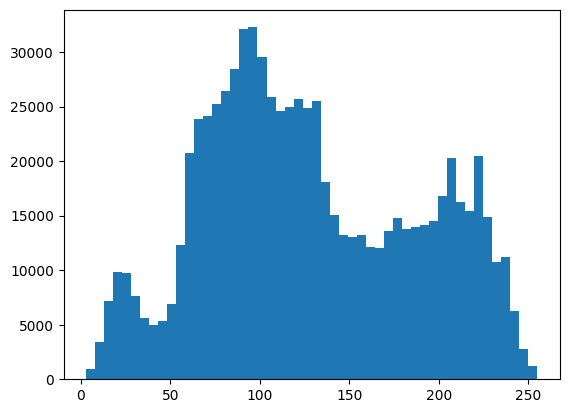

In [5]:
flat = img.flatten()
plt.hist(flat,bins=50)

The histogram with the distribution of three channels(rgb) has been completed.
As you can see, the distribution has increased by about three times on the Y-axis.
The channel tripled, but the histogram looks similar, right?
But you might wonder why it doesn't look the same.
The reason is that the formula for converting RGB to gray scale is:
$Y=0.299*R+0.587*G+0.114*B$ This is the ratio how human's eyes recognize the RGB.

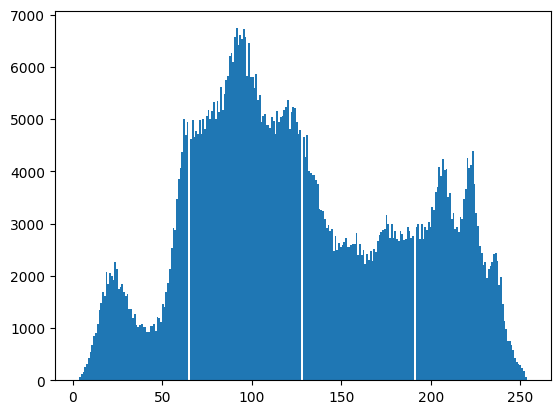

In [6]:
#hstack:horizonal stack 3차원부턴 층으로 쌓아줌
#vstack:vertical stack  3차원부턴 행 방향으로 쌓아줌
#column_stack:same as hstack after 2D 1차원일땐 열방향으로 합쳐줌
# create our own histogram function
def get_histogram(img, bins = 100, display = True):#100개 구간으로 슬라이싱한 히스토그램 데이터입니다., density=True
    min_data = np.min(img)
    max_data = np.max(img)

    dx = (max_data - min_data) / bins #bins가 한번 돌아갈때마다 x축을 그리는 구간이 dx입니다.
    x = np.zeros(bins)
    y = np.zeros(bins+1)#for문이 0~bin까지 돌기 때문에 y 배열은 x배열보다 1 커야합니다.
    for i in range(bins):
        x[i] = i*dx + min_data
    #print(img.size)
    for j in img:
        #print(j)
        bin = int((j - min_data) / dx)
        #print(y)
        y[bin] += 1
    
    y[bins-2] += y[bins-1]
    y = y[:bins]
    if display==True:
        plt.bar(x, y, width=dx)
    return np.column_stack((x, y))
    
hist = get_histogram(flat,256)


If we apply the formula of drawing histogram:
$\displaystyle P_x(j) = \sum_{i=0}^{j}P_x(i)$  
We can find that it is same with the histogram function of matplotlib    
now let's try to make a function cummulte the sum of pixels.

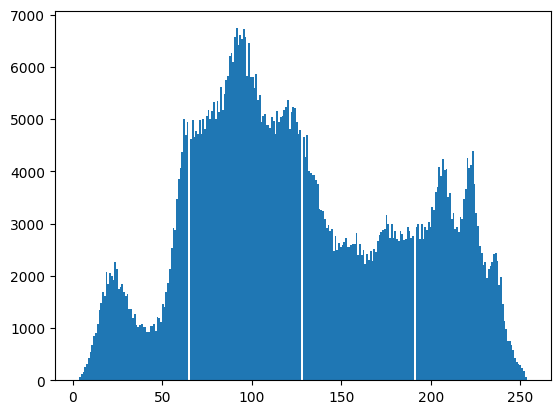

In [7]:
def cumsum(a):
    a = iter(a)
    b = [next(a)]
    for i in a:
        b.append(b[-1] + i)
    return np.array(b)

# execute the fn
hist = get_histogram(flat,256)
cs = cumsum(hist)


$\displaystyle s_k = \sum_{j=0}^{k} {\frac{n_j}{N}}$ This formula is the result of resizing a sum value from 0 to 255.

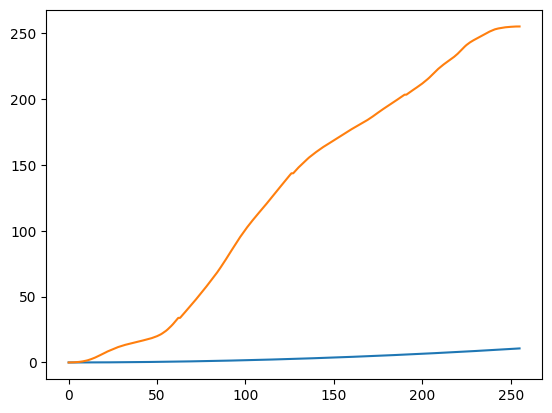

In [8]:
# re-normalize cumsum values to be between 0-255

# numerator & denomenator
nj = (cs - cs.min()) * 255
N = cs.max() - cs.min()

# re-normalize the cdf
cs = nj / N

plt.plot(cs)

Because of decimal point  
data should convert to uint type  
uint means unsigned int, same as a nature number N  
Now we can find the graph has changed little bit rough.  

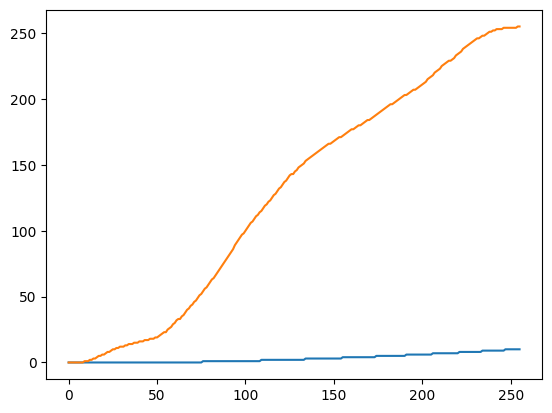

In [9]:
# cast it back to uint8 since we can't use floating point values in imgs
cs = cs.astype('uint8')

plt.plot(cs)

Cool, now we know the fundamental concept of image and the histogram!  
It is time to learn histogram equalization.  
![nn](histogram_equalization.png)  

source:wikipedia  

You don't have to be afraid. It's a simple algorithm.

$H'(v)=round(\frac{cdf(v)-cdf{min}}{(M*N)-cdf_{min}}*(L-1))$  

this is the essence of formula, let's see what is these factors exactly works  
cdf(v): cummulate function ofhistogram    
$cdf_{min}$: min value of cumsum , 1   
M*N : number of pixel, width x height    
L : Distribution area, 256    
round(v) : round    
H′(v): Equalized histogram value    

Let's apply the fomula in the function!

In [10]:
cdf = cs
# cdf의 값이 0인 경우는 mask처리를 하여 계산에서 제외
# mask처리가 되면 Numpy 계산에서 제외가 됨
# 아래는 cdf array에서 값이 0인 부분을 mask처리함
cdf_m = np.ma.masked_equal(cdf,0)

#History Equalization 공식
cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())

# Mask처리를 했던 부분을 다시 0으로 변환
cdf = np.ma.filled(cdf_m,0).astype('uint8')

img2 = cdf[img]

TypeError: Invalid shape (512, 512, 3, 2) for image data

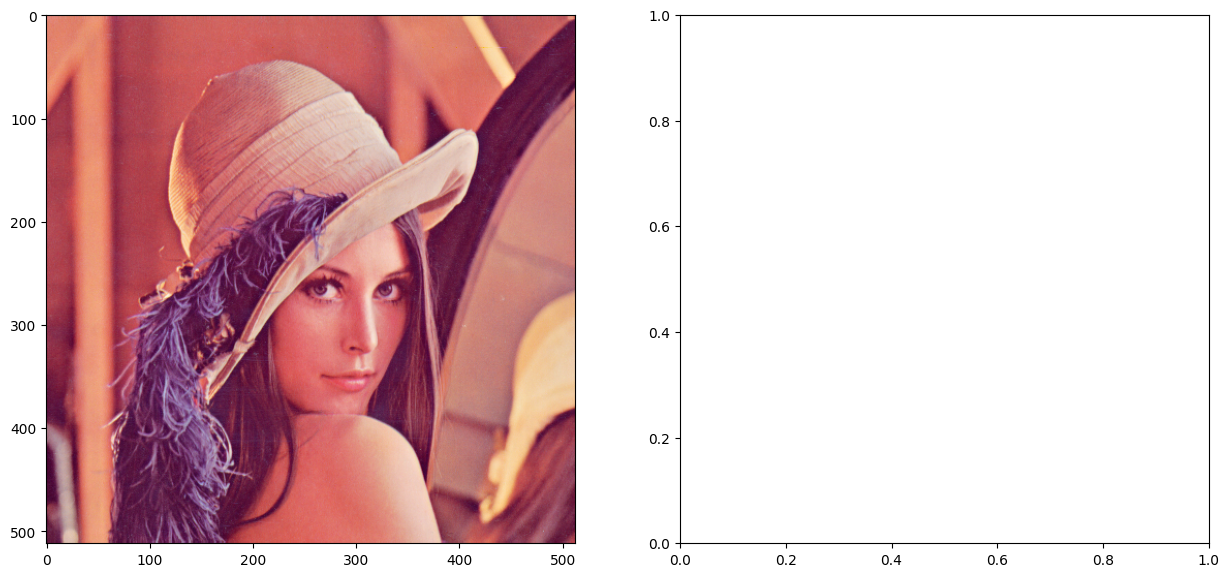

In [11]:
# set up side-by-side image display
fig = plt.figure()
fig.set_figheight(15)
fig.set_figwidth(15)

fig.add_subplot(1,2,1)
plt.imshow(img)

# display the new image
fig.add_subplot(1,2,2)
plt.imshow(img2)

plt.show(block=True)